# Supporting Code for Saccharide concentration prediction from proxy ocean samples analyzed via infrared spectroscopy and quantitative machine learning.

#### Code authored by Nicole North and Abigail Enders

#### Support Vector Regression

In [1]:
#Data Import and Visualization
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import math


#Machine Learning Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

#ML Model
from sklearn.svm import SVR

#Model and Data Analysis
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression

First we bring in all of our data.

In [2]:
path = 'PATH'
#Training Dataset and data for lab Proxies
filename = 'trainingSpectra.csv'
#List of Concentrations for the Training Set
conc = 'conc.csv'

#Read in data into dataframes
os.chdir(path)
df = pd.read_csv(filename, index_col=False)
concs = pd.read_csv(conc, index_col=False)

Each of our samples was taken in triplicate so we will need to correct the list 

In [3]:
conc_unknown = [0.2002,0.2002,0.2002,0.1502,0.1502,0.1502,0.1001,0.1001,0.1001] #Saccharide Concentration of Lab Proxies


#make list of concentrations (triplicate measurements)
conc_list = list(concs.iloc[:, 0])
conc_l2 = []
c = 0
for i in conc_list:
    while c < 3:
        conc_l2.append(i)
        c += 1
    c = 0
for i in conc_unknown:
    conc_l2.append(i)
conc = pd.DataFrame(conc_l2)


#set up spectra data
wavenumbers = df.iloc[0]
fdata = df.iloc[0:, 1:]
fdata = fdata.iloc[300:900,:]

Plot the Experimental Data for Reference

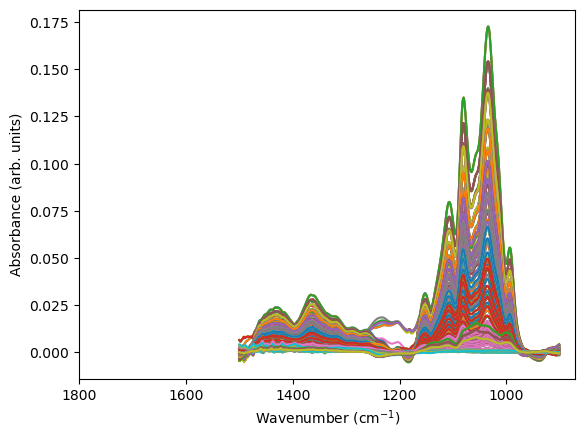

In [4]:
plt.plot(fdata)
plt.xticks([0,200,400,600,800],[1800,1600,1400,1200,1000])
plt.xlabel('Wavenumber (cm$^{-1}$)')
plt.ylabel('Absorbance (arb. units)')
plt.savefig('all_data.jpg',dpi=300)


We can now standardize the dataset using the Sklearn StandardScaler Function

StandardScaler subtracts the mean from each sample and divides by the standard deviation

In [5]:
# scale data 
sc_X = StandardScaler()
sc_y = StandardScaler()
#plt.savefig('all_data.jpg',dpi=300)

# transpose data so rows are wavenumbers
X = np.transpose(fdata)
#unset = np.transpose(unset)
# use scaler on x,y data
X = sc_X.fit_transform(X.values.astype(float))
y = sc_y.fit_transform(conc.values.astype(float))

#Separate training dataset from lab proxies
x_unknown = X[300:,:]
X = X[:300,:]
y_unknown = y[300:,:]
y = y[:300,:]

Now we can split our data into train and testing sets.

In [6]:
# train test data split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_Validate, X_test, y_validate, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

Train Model on Train Test Split Data

In [7]:
# initialize regressor & fit
regressor = SVR(kernel='rbf')
regressor.fit(X_train,y_train)

y_calibrate = regressor.predict(X_train) #Final Training Results
y_pred = regressor.predict(X_test) # Final Testing Results
y_val = regressor.predict(X_Validate)
y_un_pred = regressor.predict(x_unknown) # predict on new data

C:\Users\north.154\AppData\Local\anaconda3_1\lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [8]:
# transpose data back back to concentration after scaling previously
X_train_trans = pd.DataFrame(np.transpose(X_train)) # transpose X data from train split
X_test_trans = pd.DataFrame(np.transpose(X_test)) # transpose X data from test split
x_test = sc_X.inverse_transform(X_test)
x_test = pd.DataFrame(np.transpose(x_test))

x_unknown_test = sc_X.inverse_transform(x_unknown)
x_unknown_test = pd.DataFrame(np.transpose(x_unknown_test))

y_calibrate = y_calibrate.reshape(-1,1) # reshape y train data
y_calibrate = sc_y.inverse_transform(y_calibrate) # transform predicted y vals

y_pred = y_pred.reshape(-1,1) # reshape y test data
y_pred = sc_y.inverse_transform(y_pred) # transform predicted y vals

y_val = y_val.reshape(-1,1) # reshape y test data
y_val = sc_y.inverse_transform(y_val) # transform predicted y vals

y_un_pred = y_un_pred.reshape(-1,1) # reshape y unknown data
y_un_pred = sc_y.inverse_transform(y_un_pred) # reshape predicted y data from unknowns

y_test = sc_y.inverse_transform(y_test)
y_train = sc_y.inverse_transform(y_train)
y_validate = sc_y.inverse_transform(y_validate)

In [9]:
# print mean sq. err
print("*SVR Model Statistics*")
print('R Squared Score: %4f' % metrics.r2_score(y_test, y_pred))
print('________________________________________________________________')
print("-Errors from Calibration-")
print('RMSE: %.4f' % math.sqrt(mean_squared_error(y_train, y_train, squared = True)) + ' M')
print('Mean Absolute Error: %4f' % metrics.mean_absolute_error(y_train, y_train) + ' M')
print('________________________________________________________________')
print("-Errors from Testing Data-")
print('RMSE: %.4f' % math.sqrt(mean_squared_error(y_test, y_pred, squared = True)) + ' M')
print('Mean Absolute Error: %4f' % metrics.mean_absolute_error(y_test, y_pred) + ' M')
print('________________________________________________________________')
print("-Errors from Validation Data-")
print('RMSE: %.4f' % math.sqrt(mean_squared_error(y_val, y_validate, squared = True)) + ' M')
print('Mean Absolute Error: %4f' % metrics.mean_absolute_error(y_val, y_validate) + ' M')


*SVR Model Statistics*
R Squared Score: 0.955016
________________________________________________________________
-Errors from Calibration-
RMSE: 0.0000 M
Mean Absolute Error: 0.000000 M
________________________________________________________________
-Errors from Testing Data-
RMSE: 0.0476 M
Mean Absolute Error: 0.021941 M
________________________________________________________________
-Errors from Validation Data-
RMSE: 0.0351 M
Mean Absolute Error: 0.016585 M


In [10]:
y_un_pred = pd.DataFrame(y_un_pred).T


sample_a = (y_un_pred[0] + y_un_pred[1] + y_un_pred[2])/3
print("Sample A Actual Conc:          0.2002 M")
print("Sample A SVR Predicted Conc:  "+ str(sample_a.values)+ ' M')
print("Sample A Difference:          " + str(0.2002 - sample_a.values)+ ' M')
print("Sample A Percentage:          " + str((sample_a.values /0.2002)*100)+ ' M')
print("_______________________________________________________")

sample_b = (y_un_pred[3] + y_un_pred[4] + y_un_pred[5])/3
print("Sample B Actual Conc:          0.1502 M")
print("Sample B SVR Predicted Conc:  "+ str(sample_b.values)+ ' M')
print("Sample B Difference:          " + str(0.1502 - sample_b.values)+ ' M')
print("Sample B Percentage:          " + str((sample_b.values /0.1502)*100)+ ' M')
print("_______________________________________________________")

sample_c = (y_un_pred[6] + y_un_pred[7] + y_un_pred[8])/3
print("Sample C Actual Conc:          0.1001 M")
print("Sample C SVR Predicted Conc:  "+ str(sample_c.values)+ ' M')
print("Sample C Difference:          " + str(0.1001 - sample_c.values)+ ' M')
print("Sample C Percentage:          " + str((sample_c.values /0.100)*100)+ ' M')



Sample A Actual Conc:          0.2002 M
Sample A SVR Predicted Conc:  [0.19378671] M
Sample A Difference:          [0.00641329] M
Sample A Percentage:          [96.79655737] M
_______________________________________________________
Sample B Actual Conc:          0.1502 M
Sample B SVR Predicted Conc:  [0.13939388] M
Sample B Difference:          [0.01080612] M
Sample B Percentage:          [92.8055094] M
_______________________________________________________
Sample C Actual Conc:          0.1001 M
Sample C SVR Predicted Conc:  [0.09224692] M
Sample C Difference:          [0.00785308] M
Sample C Percentage:          [92.2469223] M


In [11]:
results = pd.DataFrame(y_test)
results.columns = (['Actual Concentration'])
results['SVR Predicted Concentrations'] = y_pred
results['Difference'] = results['Actual Concentration'] - results['SVR Predicted Concentrations']


(-0.3, 0.3)

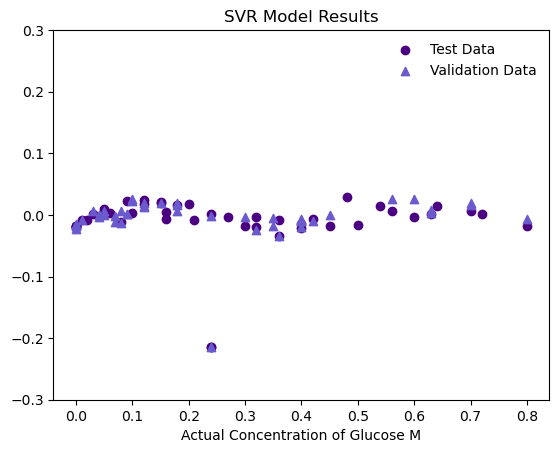

In [12]:
plt.scatter(results['Actual Concentration'], results['Difference'], marker = 'o', color = 'indigo', label = "Test Data")
plt.scatter(y_validate, y_validate - y_val, marker = '^', color = "slateblue", label = 'Validation Data' )
plt.legend(frameon = False)
plt.title('SVR Model Results')
#plt.ylabel('Concentration Difference (Actual - Predicted) M')
plt.xlabel('Actual Concentration of Glucose M')
plt.ylim(-0.3,0.3)